## WW_step1_2_FEM_Do.ipynb


In [61]:
import sys
from pathlib import Path

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from dynamics_tools import shape_functions, element_stiffness, element_mass, compute_f1
from scipy.linalg import eigh

NOTEBOOK_DIR = Path.cwd().resolve()
if not (NOTEBOOK_DIR / "dynamics_tools.py").exists():
    for parent in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
        candidate = parent / "CIEM5220" / "Windturbine"
        if (candidate / "dynamics_tools.py").exists():
            NOTEBOOK_DIR = candidate
            break

sys.path.insert(0, str(NOTEBOOK_DIR))

x=sp.Symbol('x')

# ====== GEOMETRY & MATERIAL ========
D0 = 5                          # [m]  
t=0.08                          # [m]  
Di = D0-2*t                     # [m]
A = np.pi/4*(D0**2-Di**2)       # [m^2]
I = np.pi/64*(D0**4-Di**4)      # [m^-4]
rho = 7850                      # steel [kg/m^3] ##
E = 210e9                       # [Pa]

EI=E*I
rhoA=rho*A

Hw=36.0                         # [m]
Ha=108.0                        # [m]
L=Hw+Ha                         # [m]  

M_nacelle=6e5       # [kg] 

# ====== ROTOR PARAMETERS ========
Omega_max=7.6                   # [rpm]
f_1P=Omega_max/60               # [Hz]
f_3P=3*f_1P                     # [Hz]
f_target=1.1*f_1P               # [Hz]

print(f"1P frequency: {f_1P:.4f} Hz")
print(f"3P frequency: {f_3P:.4f} Hz")
print(f"Target f1 (>=1.1*1P): {f_target:.4f} Hz")



1P frequency: 0.1267 Hz
3P frequency: 0.3800 Hz
Target f1 (>=1.1*1P): 0.1393 Hz


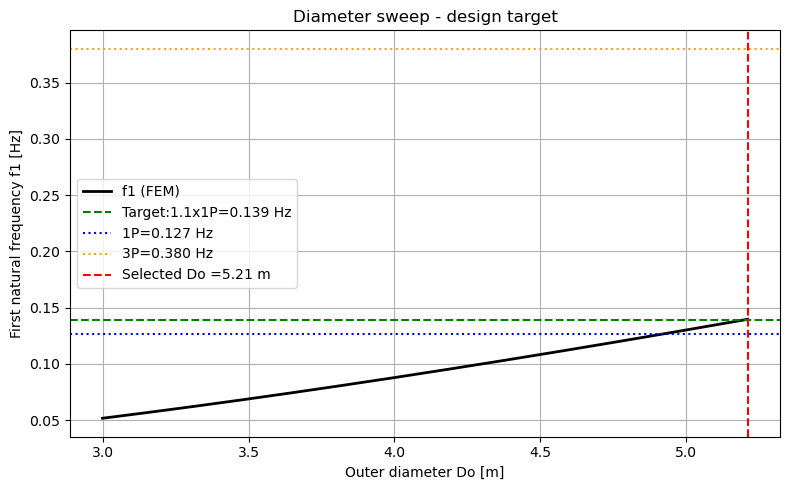


 Diameter Tuning
D/t ratio:        90
D0=               5.210 m
t=                0.0579m
f1 achieved=      0.1397 Hz
Margin above 1P = 10.3%


In [62]:
# ====== DIAMETER TUNING =======

Dt_ratio=90
D0_range=np.arange(3.0, 10.0, 0.01) # sweep diameters [m]

elements=12
le=L/elements
elem_w=int(Hw/le)        # elements in submerged zone
elem_a=elements-elem_w   # elements in air zone 

nodes          = elements+1
DOF            = 2             # (w, theta)
ndof           = nodes*DOF

# store results for plotting

D0_list=[]
f1_list=[]

for D0_try in D0_range:
    f1_try=compute_f1(elements, ndof, Dt_ratio, D0_try, E, rho, 
                      Hw, Ha, L, elem_w, elem_a, le, M_nacelle)
    D0_list.append(D0_try)
    f1_list.append(f1_try)
    if f1_try>= f_target:
        D0=D0_try
        t=D0/Dt_ratio
        break
# plot f1 vs D0
fig_sweep, ax_sweep=plt.subplots(figsize=(8,5))
ax_sweep.plot(D0_list, f1_list, 'k', linewidth=2, label='f1 (FEM)')
ax_sweep.axhline(f_target, color='green', linestyle='--', label=f'Target:1.1x1P={f_target:.3f} Hz')
ax_sweep.axhline(f_1P, color='blue', linestyle=':', label=f'1P={f_1P:.3f} Hz')
ax_sweep.axhline(f_3P, color='orange', linestyle=':', label=f'3P={f_3P:.3f} Hz')
ax_sweep.axvline(D0, color='red', linestyle='--', label=f'Selected Do ={D0:.2f} m')
ax_sweep.set_xlabel('Outer diameter Do [m]')
ax_sweep.set_ylabel('First natural frequency f1 [Hz]')
ax_sweep.set_title('Diameter sweep - design target')
ax_sweep.legend()
ax_sweep.grid(True)
plt.tight_layout()
plt.show()


print(f"\n Diameter Tuning")
print(f"D/t ratio:        {Dt_ratio}")
print(f"D0=               {D0:.3f} m")
print(f"t=                {t:.4f}m")
print(f"f1 achieved=      {f1_try:.4f} Hz")
print(f"Margin above 1P = {(f1_try/f_1P-1)*100:.1f}%")



In [63]:
# update cross-section with tuned diameter
Di=D0-2*t
A=np.pi/4*(D0**2-Di**2)
I=np.pi/64*(D0**4-Di**4)
EI=E*I
rhoA=rho*A

print(f"A={A:.6f}m^2")
print(f"I={I:.6f} m^4")



A=0.936980m^2
I=3.109321 m^4


In [64]:
# ====== FE MODEL SETUP ========

B = shape_functions(le)
Ke = element_stiffness(le, EI)
Me = element_mass(le, rhoA)

# ======= ASSEMBLY ========
K =np.zeros((ndof,ndof))
M =np.zeros((ndof,ndof))

for e in range(elements):
    dofs=[2*e, 2*e+1, 2*e+2, 2*e+3]
    for i in range(4):
        for j in range(4):
            K[dofs[i], dofs[j]] += Ke[i,j]
            M[dofs[i], dofs[j]] += Me[i,j]

# ===== BOUNDARY CONDITIONS =======
# clamped base: remove DOFs 0 and 1
free=np.arange(2, ndof)
K_free=K[np.ix_(free,free)]
M_free=M[np.ix_(free,free)]

# ====== SANITY CHECK ========
# Uniform load over full length, no nacelle mass
# Analytical: u_tip = qL^4/8EI, M_mudline= qL^2/2
q_check=1e3             # [N/m] uniform load
f_check=np.zeros(ndof)

for e in range(elements):
    fe=np.array([
        float(sp.integrate(Ni*q_check, (x, 0, le))) for Ni in B
    ])
    dofs=[2*e, 2*e+1, 2*e+2, 2*e+3]
    for i in range(4):
        f_check[dofs[i]]+=fe[i]
    

f_check_free         = f_check[free]
u_check              = np.linalg.solve(K_free, f_check_free)
u_tip_FE             = u_check[-2]
u_check_full         = np.zeros(ndof)
u_check_full[free]   = u_check
u_e0                 = u_check_full[0:4]
M_mudline_FE         = EI*sum(
    float(sp.diff(Ni, x, 2).subs(x, 0))*u_e0[i]
    for i, Ni in enumerate(B)
)
u_tip_analytical     = q_check*L**4/(8*EI)
M_mudline_analytical = q_check*L**2/2

print(f"\n--- Sanity Check (uniform load q={q_check} N/m, no nacelle)---")
print(f"Tip deflection FE: {u_tip_FE:.6f} m")
print(f"Tip deflection Analytical: {u_tip_analytical:.6f} m")
print(f"Mudline moment FE: {M_mudline_FE/1e6:.3f} MNm")
print(f"Mudline moment Analytical: {M_mudline_analytical/1e6:.3f} MNm")




--- Sanity Check (uniform load q=1000.0 N/m, no nacelle)---
Tip deflection FE: 0.082314 m
Tip deflection Analytical: 0.082314 m
Mudline moment FE: 10.356 MNm
Mudline moment Analytical: 10.368 MNm


In [65]:
#========= + NACELLE MASS ===========
M[ndof-2, ndof-2]+=M_nacelle
M_free=M[np.ix_(free, free)]

# ==== EIGENVALUE ANALYSIS =======
eigenvalues, eigenvectors=eigh(K_free, M_free)
omega=np.sqrt(eigenvalues)
freq=omega/(2*np.pi)

print(f"\n---Natural frequencies ---")
print(f"Mode 1: {freq[0]:.4f} Hz (target >={f_target:.4f} Hz)")
print(f"Mode 2: {freq[1]:.4f} Hz")
print(f"Soft-stiff window: {f_1P:.4f}-{f_3P:.4f} Hz")




---Natural frequencies ---
Mode 1: 0.1397 Hz (target >=0.1393 Hz)
Mode 2: 1.2122 Hz
Soft-stiff window: 0.1267-0.3800 Hz


In [66]:
# ====== RAYLEIGH DAMPING ========
#Borth modes have 2% critical damping as per assignment

zeta1=0.02           # damping ratio mode 1
zeta2=0.02           # damping ratio mode 2
w1 = omega[0]        # first natural frequency [rad/s]
w2 = omega[1]        # second natural frequency [rad/s]

alpha   = 2*w1*w2*(zeta1*w2-zeta2*w1)/(w2**2-w1**2)
beta    = 2*(zeta2*w2-zeta1*w1)/(w2**2-w1**2)
C_free  = alpha * M_free + beta * K_free

print(f"\n--- Rayleigh Damping ---")
print(f"alpha={alpha:.6f}")
print(f"beta={beta:.6f}")




--- Rayleigh Damping ---
alpha=0.031477
beta=0.004709


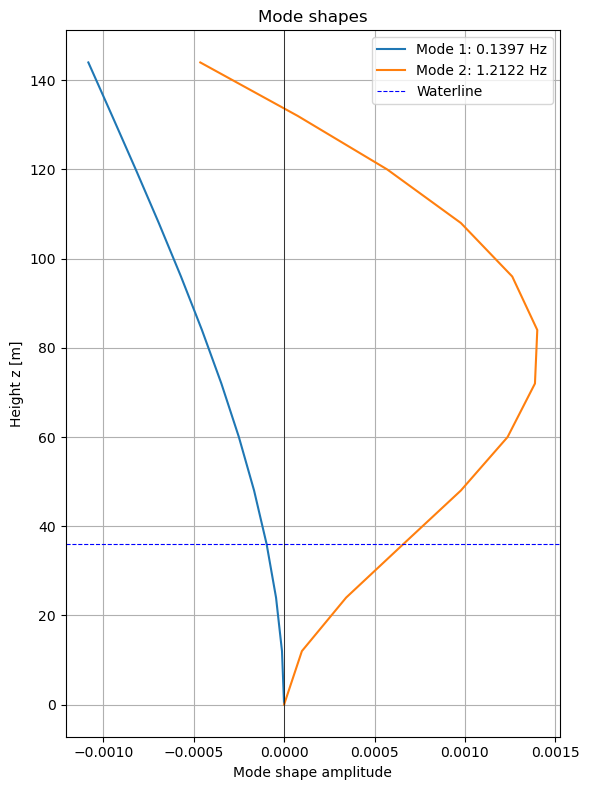

In [67]:
# ======= POST-PROCESSING =========

# Mode shapes

fig3, ax=plt.subplots(figsize=(6, 8))

# height coordinates of each node
z_nodes=np.array([i*le for i in range(nodes)])

for mode in range(2):
    # extract lateral displacement DOFs (every other DOF starting from 0)
    phi=eigenvectors[:,mode]  # full free DOF eigenvector

    # lateral displacements are even indices of free DOFs
    phi_lateral=phi[0::2]  # every other entry starting from 0
    phi_plot=np.concatenate([[0], phi_lateral])

    ax.plot(phi_plot, z_nodes, label=f'Mode {mode+1}: {freq[mode]:.4f} Hz')

ax.axhline(Hw, color= 'blue', linestyle='--', linewidth=0.8, label='Waterline')
ax.axvline(0,color='k', linewidth=0.5)
ax.set_xlabel('Mode shape amplitude')
ax.set_ylabel('Height z [m]')
ax.set_title('Mode shapes')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()



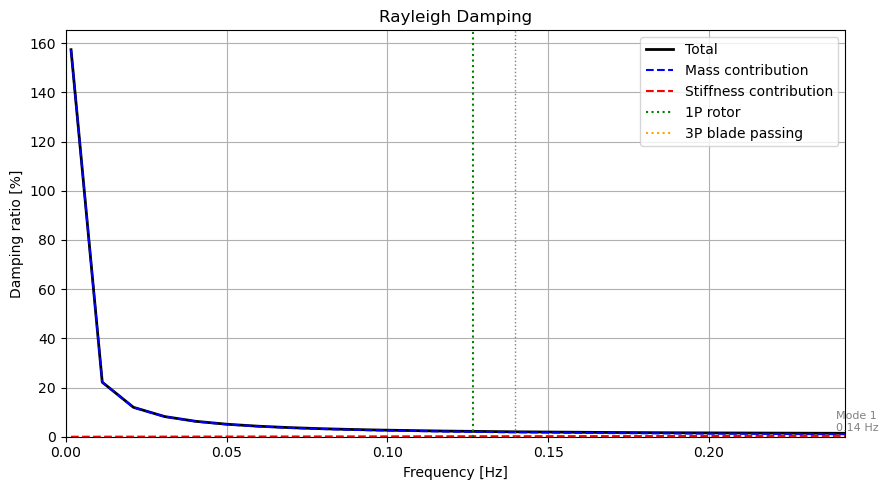

In [68]:
#--- Rayleigh damping
omega_range=np.linspace(0.01, 4*w2,500) #frequency range [rad/s]
zeta_total=alpha/(2*omega_range)+beta*omega_range/2
zeta_mass = alpha/(2*omega_range)  # mass term - dominates at low frequencies
zeta_stiff=beta*omega_range/2    # stiffness term - dominates at high frequencies

fig2, ax = plt.subplots(figsize=(9,5))

ax.plot(omega_range/(2*np.pi), zeta_total*100, 'k', linewidth=2, label='Total')
ax.plot(omega_range/(2*np.pi), zeta_mass*100, 'b--', linewidth=1.5,label= 'Mass contribution')
ax.plot(omega_range/(2*np.pi), zeta_stiff*100, 'r--', linewidth=1.5, label='Stiffness contribution')

ax.axvline(w1/(2*np.pi), color='gray', linestyle=':', linewidth=1)
ax.axvline(w2/(2*np.pi), color='gray', linestyle=':', linewidth=1)
ax.axvline(f_1P, color='green', linestyle=':', linewidth=1.5, label='1P rotor')
ax.axvline(f_3P, color='orange', linestyle=':', linewidth=1.5, label='3P blade passing')

ax.annotate(f'Mode 1\n{w1/(2*np.pi):.2f} Hz',
            xy=(w1/(2*np.pi), zeta1*100), xytext=(w1/(2*np.pi)+0.1, zeta1*100+0.3),
            fontsize=8, color='gray')
ax.annotate(f'Mode 2\n{w2/(2*np.pi):.2f} Hz',
            xy=(w2/(2*np.pi), zeta2*100), xytext=(w2/(2*np.pi)+0.1, zeta2*100+0.3),
            fontsize=8, color='gray')

ax.set_xlim(0,4*w2/(2*np.pi)/20)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylim(6)
ax.set_ylabel('Damping ratio [%]')
ax.set_title('Rayleigh Damping')
ax.legend()
ax.grid(True)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()




In [69]:
# verify damping ratios

zeta1_check=alpha/(2*w1)+beta*w1/2
zeta2_check=alpha/(2*w2)+beta*w2/2

print(f"Damping at mode 1: {zeta1_check*100:.2f}%")
print(f"Damping at mode 2: {zeta2_check*100:.2f}%")

output_dir = NOTEBOOK_DIR / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

# === SAVE OUTPUTS =====
#np.savez(output_dir / 'fem_results.npz',
#    K_free         = K_free,
#    M_free         = M_free, 
#    C_free        = C_free, 
#    freq           = freq,
#    omega          = omega, 
#    eigenvectors   = eigenvectors, 
#    D0             =D0,
#    t              =t,
#    EI             =EI,
#    rhoA           =rhoA,
#    le             =le,
#    Hw             =Hw,
#    Ha             =Ha,
#    L              =L,
#    elem_w         =elem_w, 
#    elem_a         =elem_a, 
#    ndof           =ndof, 
#    M_nacelle      =M_nacelle
#)
print("FEM results saved to outputs/fem_results.npz")

Damping at mode 1: 2.00%
Damping at mode 2: 2.00%
FEM results saved to outputs/fem_results.npz


## WW_step3_spectra.ipynb


In [70]:
# ================================================
# CIEM5220 - Wave and Wind loads
#     Waterbound Windturbine 
#       STEP 3 - SPECTRA
# ================================================

import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
for parent in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    candidate = parent / "CIEM5220" / "Windturbine"
    if (candidate / "dynamics_tools.py").exists():
        NOTEBOOK_DIR = candidate
        break

sys.path.insert(0, str(NOTEBOOK_DIR))

import numpy as np
import matplotlib.pyplot as plt
from dynamics_tools import S_jonswap
from scipy.optimize import brentq

#==== LOAD FEM RESULTS =====
fem=np.load(NOTEBOOK_DIR / 'outputs' / 'fem_results.npz')

freq =fem['freq']
D0 = float(fem['D0'])
le=float(fem['le'])
Hw=float(fem['Hw'])
Ha= float(fem['Ha'])
L=float(fem['L'])
elem_w=int(fem['elem_w'])
elem_a=int(fem['elem_a'])
ndof=int(fem['ndof'])

elements=elem_w+elem_a
nodes=elements+1
z_nodes=np.array([i*le for i in range(nodes)])
z_above=z_nodes-Hw

f1=freq[0]
f2=freq[1]
T1=1/f1

print(f"Loaded FEM results")
print(f"f1={f1:.4f} Hz, T1={T1:.2f} s")
print(f"f2={f2:.4f} Hz")


Loaded FEM results
f1=0.1397 Hz, T1=7.16 s
f2=1.2122 Hz


In [71]:
# ====== LOAD CASES =======
g=9.81
F_fetch=180e3  # fetch [m]
z0=0.001       # roughness length, open sea [m]

# LC2 - reference wind speed given, derive wave period
U10_LC2 = 19.0
Tp_LC2= 0.286*(g*F_fetch/U10_LC2**2)**0.33*U10_LC2/g
Hs_LC2=0.0016*np.sqrt(g*F_fetch/U10_LC2**2)*U10_LC2**2/g

# LC1 - Wave peak period equals first natural period, derive wind speed
Tp_LC1=T1
U10_LC1=brentq(
    lambda U: 0.286*(g*F_fetch/U**2)**0.33*U/g-Tp_LC1, 
    1.0, 50.0
)
Hs_LC1=0.0016*np.sqrt(g*F_fetch/U10_LC1**2)*U10_LC1**2/g

print(f"\nLoad Cases")
print(f"LC1: U10= {U10_LC1:.2f} m/s, Tp= {Tp_LC1:.2f} s, Hs= {Hs_LC1:.2f}")
print(f"LC2: U10= {U10_LC2:.2f} m/s, Tp= {Tp_LC2:.2f} s, Hs= {Hs_LC2:.2f}")




Load Cases
LC1: U10= 9.26 m/s, Tp= 7.16 s, Hs= 2.01
LC2: U10= 19.00 m/s, Tp= 9.14 s, Hs= 4.12


In [72]:
# ===== MEAN WIND PROFILE =====
z0=0.001 # roughness length, open sea [m]

def mean_wind(U10, z, z0):
    z_pos=np.maximum(z, z0)
    return U10*np.log(z_pos/z0)/np.log(10.0/z0)

# only valid above waterline

U_mean_LC1=np.where(z_above > 0, mean_wind(U10_LC1, z_above, z0), 0.0)
U_mean_LC2=np.where(z_above > 0, mean_wind(U10_LC2, z_above, z0), 0.0)

print(f"\n Mean Wind Profile")
print(f"LC1 tip wind speed: {U_mean_LC1[-1]:.2f} m/s")
print(f"LC2 tip wind speed: {U_mean_LC2[-1]:.2f} m/s")




 Mean Wind Profile
LC1 tip wind speed: 11.66 m/s
LC2 tip wind speed: 23.91 m/s


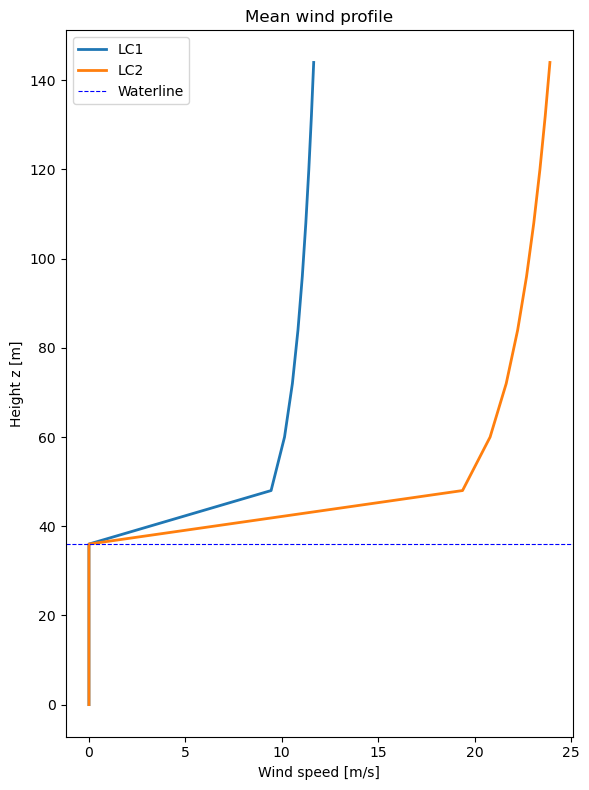

In [73]:
#plot
fig, ax=plt.subplots(figsize=(6, 8))
ax.plot(U_mean_LC1, z_nodes, linewidth=2, label='LC1')
ax.plot(U_mean_LC2, z_nodes, linewidth=2, label='LC2')
ax.axhline(Hw, color='blue', linestyle='--', linewidth=0.8, label='Waterline')
ax.set_xlabel('Wind speed [m/s]')
ax.set_ylabel('Height z [m]')
ax.set_title('Mean wind profile')
plt.tight_layout()
plt.legend()
plt.show()



In [74]:
# ===== KAIMAL SPECTRUM ====
N_freq=1000
f_max=2*f2                   # twice second natural frequency [Hz]
f_axis=np.linspace(0.01, f_max, N_freq) # [Hz], avoid f=0

I_u=0.06                     # turbulence intensity, offshore [-]
L_u=180                      # turbulence length scale [m]

def kaimal(f, U, I_u, L_u):
    sigma_u=I_u*U            # turbulence std dev [m/s]
    return 4*sigma_u**2*(L_u/U)/(1+6*f*L_u/U)**(5/3)

# compute at each air node for both load cases
# shape: (n_air_nodes, N_freq)
air_nodes= np.where(z_above > 0)[0]

S_kaimal_LC1=np.zeros((len(air_nodes), N_freq))
S_kaimal_LC2=np.zeros((len(air_nodes), N_freq))

for i, node in enumerate(air_nodes):
    S_kaimal_LC1[i, :]=kaimal(f_axis, U_mean_LC1[node], I_u, L_u)
    S_kaimal_LC2[i, :]=kaimal(f_axis, U_mean_LC2[node], I_u, L_u)

print(f"\ Kaimal Spectrum")
print(f"Frequency range: {f_axis[0]:.3f}-{f_axis[-1]:.3f} Hz")
print(f"Number of air nodes: {len(air_nodes)}")



\ Kaimal Spectrum
Frequency range: 0.010-2.424 Hz
Number of air nodes: 9


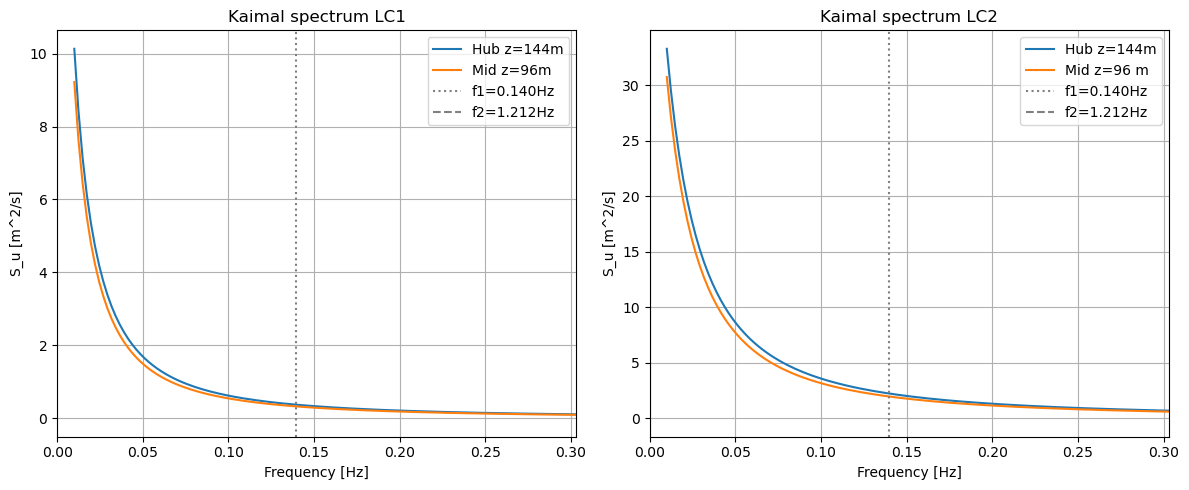

In [75]:
# plot at hub height (top node) and mid-height for both load cases
fig, axes= plt.subplots(1, 2, figsize=(12,5))
axes[0].plot(f_axis, S_kaimal_LC1[-1,:], label=f'Hub z={z_nodes[air_nodes[-1]]:.0f}m')
axes[0].plot(f_axis, S_kaimal_LC1[len(air_nodes)//2, :],
             label=f"Mid z={z_nodes[air_nodes[len(air_nodes)//2]]:.0f}m")
axes[0].axvline(f1, color='gray', linestyle=':', label=f'f1={f1:.3f}Hz')
axes[0].axvline(f2, color='gray', linestyle='--', label=f'f2={f2:.3f}Hz')
axes[0].set_xlim(0, f_max/8)
axes[0].set_xlabel('Frequency [Hz]')
axes[0].set_ylabel('S_u [m^2/s]')
axes[0].set_title('Kaimal spectrum LC1')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(f_axis, S_kaimal_LC2[-1, :], label=f'Hub z={z_nodes[air_nodes[-1]]:.0f}m')
axes[1].plot(f_axis, S_kaimal_LC2[len(air_nodes)//2, :],
             label=f'Mid z={z_nodes[air_nodes[len(air_nodes)//2]]:.0f} m')
axes[1].axvline(f1, color='gray', linestyle=':', label=f'f1={f1:.3f}Hz')
axes[1].axvline(f2, color='gray', linestyle='--', label=f'f2={f2:.3f}Hz')
axes[1].set_xlim(0, f_max/8)
axes[1].set_xlabel('Frequency [Hz]')
axes[1].set_ylabel('S_u [m^2/s]')
axes[1].set_title('Kaimal spectrum LC2')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()



In [76]:
# ===== JONSWAP SPECTRUM ======
gamma=3.3 #peak enhancement factor


omega_p_LC1=2*np.pi/Tp_LC1
omega_p_LC2=2*np.pi/Tp_LC2

omega_axis=2*np.pi*f_axis # convert Hz to rad/s

print(f"omega_axis range: {omega_axis[0]:.3f} to {omega_axis[-1]:.3f} rad/s")
print(f"omega_p LC1: {omega_p_LC1:.3f} rad/s")
print(f"omega_p LC2: {omega_p_LC2:.3f} rad/s")



omega_axis range: 0.063 to 15.232 rad/s
omega_p LC1: 0.878 rad/s
omega_p LC2: 0.687 rad/s


In [77]:
def compute_alpha(Hs_target, omega_axis, omega_p, gamma):
    alpha_try=0.0081
    for _ in range(100):
        S_try=S_jonswap(alpha_try, omega_axis, omega_p, gamma)
        domega=omega_axis[1]-omega_axis[0]
        Hs_try=4*np.sqrt(np.sum(S_try*domega))
        alpha_try*=(Hs_target/Hs_try)**2
    return alpha_try

alpha_LC1=compute_alpha(Hs_LC1, omega_axis, omega_p_LC1, gamma)
alpha_LC2=compute_alpha(Hs_LC2, omega_axis, omega_p_LC2, gamma)

print(f"alpha LC1: {alpha_LC1:.6f}")
print(f"alpha LC2: {alpha_LC2:.6f}")



alpha LC1: 0.005091
alpha LC2: 0.008062


In [78]:
S_jonswap_LC1=S_jonswap(alpha_LC1, omega_axis, omega_p_LC1, gamma)
S_jonswap_LC2=S_jonswap(alpha_LC2, omega_axis, omega_p_LC2, gamma)

print(f"\n JONSWAP Spectrum")
print(f"LC1: omega_p={omega_p_LC1:.4f} rad/s, Tp= {Tp_LC1:.2f}s")
print(f"LC2: omega_p={omega_p_LC2:.4f} rad/s, Tp= {Tp_LC2:.2f}s")




 JONSWAP Spectrum
LC1: omega_p=0.8776 rad/s, Tp= 7.16s
LC2: omega_p=0.6874 rad/s, Tp= 9.14s


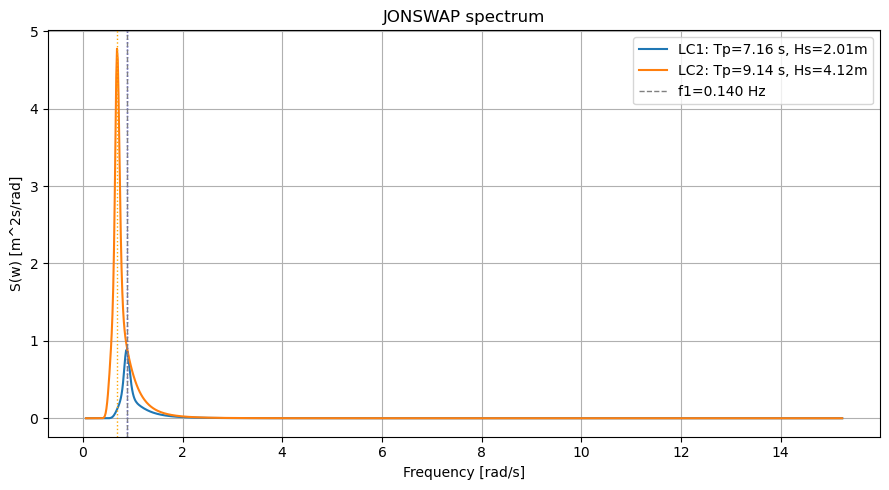

In [79]:
fig, ax= plt.subplots(figsize=(9,5))
ax.plot(omega_axis, S_jonswap_LC1, label=f'LC1: Tp={Tp_LC1:.2f} s, Hs={Hs_LC1:.2f}m')
ax.plot(omega_axis, S_jonswap_LC2, label=f'LC2: Tp={Tp_LC2:.2f} s, Hs={Hs_LC2:.2f}m')
ax.axvline(omega_p_LC1, color='blue', linestyle=':', linewidth=1)
ax.axvline(omega_p_LC2, color='orange', linestyle=':', linewidth=1)
ax.axvline(2*np.pi*f1, color='gray', linestyle='--', linewidth=1, label=f'f1={f1:.3f} Hz')
ax.set_xlabel('Frequency [rad/s]')
ax.set_ylabel('S(w) [m^2s/rad]')
ax.set_title('JONSWAP spectrum')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()



In [80]:
# ===== CO-SPECTRA =====
# Coherence decay coefficient (IEC standard)
a_coh =12.0

def coherence(f, zi, zj, U_mean_i, U_mean_j, a_coh):
    U_avg=0.5*(U_mean_i+U_mean_j)
    dz=abs(zi-zj)
    return np.exp(-a_coh*f*dz/U_avg)

# co-spectrum between nodes i and j
def co_spectrum(f, zi, zj, U_i, U_j, I_u, L_u, a_coh):
    Si=kaimal(f, U_i, I_u, L_u)
    Sj=kaimal(f, U_j, I_u, L_u)
    coh=coherence(f, zi, zj, U_i, U_j, a_coh)
    return np.sqrt(Si*Sj)*coh

# build co-spectrum matrix at each frequency
# shape: (n_air_nodes, n_air_nodes, N_freq)
n_air=len(air_nodes)
S_co_LC1=np.zeros((n_air, n_air, N_freq))
S_co_LC2=np.zeros((n_air, n_air, N_freq))

for i in range(n_air):
    for j in range(n_air):
        zi=z_above[air_nodes[i]]
        zj=z_above[air_nodes[j]]
        U_i_LC1=U_mean_LC1[air_nodes[i]]
        U_j_LC1=U_mean_LC1[air_nodes[j]]
        U_i_LC2=U_mean_LC2[air_nodes[i]]
        U_j_LC2=U_mean_LC2[air_nodes[j]]
        S_co_LC1[i,j,:]=co_spectrum(f_axis, zi, zj,
                                    U_i_LC1, U_j_LC1, I_u, L_u, a_coh)
        S_co_LC2[i,j,:]=co_spectrum(f_axis, zi, zj,
                                    U_i_LC2, U_j_LC2, I_u, L_u, a_coh)

print(f"\n Co-spectra")
print(f"Co-spectrum matrix shape: {S_co_LC1.shape}")
print(f"Diagonal check (should equal auto-spectrum at node 0):")
print(f"S_co[0,0] at f=0.14 Hz: {S_co_LC1[0,0,np.argmin(abs(f_axis-0.14))]:.4f}")
print(f" S_kaimal[0] at f=0.14 Hz: {S_kaimal_LC1[0,np.argmin(abs(f_axis-0.14))]:.4f}")




 Co-spectra
Co-spectrum matrix shape: (9, 9, 1000)
Diagonal check (should equal auto-spectrum at node 0):
S_co[0,0] at f=0.14 Hz: 0.2165
 S_kaimal[0] at f=0.14 Hz: 0.2165


In [81]:
domega_check=omega_axis[1]-omega_axis[0]
print(f"Hs check before save LC1: {4*np.sqrt(np.sum(S_jonswap_LC1*domega_check)):.3f} m")
print(f"Hs check before save LC2: {4*np.sqrt(np.sum(S_jonswap_LC2*domega_check)):.3f} m")


Hs check before save LC1: 2.008 m
Hs check before save LC2: 4.118 m


In [82]:
#==== SAVE OUTPUTS ======
output_dir = NOTEBOOK_DIR / 'outputs'
output_dir.mkdir(parents=True, exist_ok=True)

np.savez(output_dir / 'spectra_results.npz',
    #load case parameters
    U10_LC1=np.array([U10_LC1]),
    U10_LC2=np.array([U10_LC2]),
    Tp_LC1=np.array([Tp_LC1]),
    Tp_LC2=np.array([Tp_LC2]),
    Hs_LC1=np.array([Hs_LC1]),
    Hs_LC2=np.array([Hs_LC2]),
    #frequency axis
    f_axis=f_axis,
    omega_axis=omega_axis,
    # wind profiles
    U_mean_LC1=U_mean_LC1,
    U_mean_LC2=U_mean_LC2,
    z_nodes=z_nodes,
    z_above=z_above,
    air_nodes=air_nodes,
    # Kaimal spectra
    S_kaimal_LC1=S_kaimal_LC1,
    S_kaimal_LC2=S_kaimal_LC2,
    #co-spectra
    S_co_LC1=S_co_LC1,
    S_co_LC2=S_co_LC2,
    #JONSWAP
    S_jonswap_LC1=S_jonswap_LC1,
    S_jonswap_LC2=S_jonswap_LC2,
    omega_p_LC1=np.array([omega_p_LC1]),
    omega_p_LC2=np.array([omega_p_LC2])
)
print("\nSpectra results saved to outputs/spectra_results.npz")


Spectra results saved to outputs/spectra_results.npz


## WW_step4_timeseries.ipynb


In [83]:
# ================================================
# CIEM5220 - Wave and Wind loads
#     Waterbound Windturbine 
#       STEP 4 - TIMESERIES
# ================================================

import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
for parent in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    candidate = parent / "CIEM5220" / "Windturbine"
    if (candidate / "dynamics_tools.py").exists():
        NOTEBOOK_DIR = candidate
        break

sys.path.insert(0, str(NOTEBOOK_DIR))

import numpy as np
import matplotlib.pyplot as plt


In [84]:
#==== LOAD FEM RESULTS =====
fem=np.load(NOTEBOOK_DIR / 'outputs' / 'fem_results.npz')

freq =fem['freq']
D0 = float(fem['D0'])
le=float(fem['le'])
Hw=float(fem['Hw'])
Ha= float(fem['Ha'])
L=float(fem['L'])
elem_w=int(fem['elem_w'])
elem_a=int(fem['elem_a'])
ndof=int(fem['ndof'])

elements=elem_w+elem_a
nodes=elements+1
f1=freq[0]
f2=freq[1]



In [85]:
# ====== LOAD SPECTRA RESULTS ======

spec=np.load(NOTEBOOK_DIR / 'outputs' / 'spectra_results.npz')

f_axis= spec['f_axis']
omega_axis=spec['omega_axis']
U10_LC1=float(spec['U10_LC1'])
U10_LC2=float(spec['U10_LC2'])
Tp_LC1=float(spec['Tp_LC1'])
Tp_LC2=float(spec['Tp_LC2'])
Hs_LC1=float(spec['Hs_LC1'])
Hs_LC2=float(spec['Hs_LC2'])
U_mean_LC1=spec['U_mean_LC1']
U_mean_LC2=spec['U_mean_LC2']
z_nodes=spec['z_nodes']
z_above=spec['z_above']
air_nodes=spec['air_nodes']
S_kaimal_LC1=spec['S_kaimal_LC1']
S_kaimal_LC2=spec['S_kaimal_LC2']
S_co_LC1=spec['S_co_LC1']
S_co_LC2=spec['S_co_LC2']
S_jonswap_LC1=spec['S_jonswap_LC1']
S_jonswap_LC2=spec['S_jonswap_LC2']
omega_p_LC1=float(spec['omega_p_LC1'])
omega_p_LC2=float(spec['omega_p_LC2'])



C:\Users\gabri\AppData\Local\Temp\ipykernel_23860\3863092988.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  U10_LC1=float(spec['U10_LC1'])
C:\Users\gabri\AppData\Local\Temp\ipykernel_23860\3863092988.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  U10_LC2=float(spec['U10_LC2'])
C:\Users\gabri\AppData\Local\Temp\ipykernel_23860\3863092988.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Tp_LC1=float(spec['Tp_LC1'])
C:\Users\gabri\AppData\Local\Temp\ipyke

In [86]:
# ======== TIME =========
dt=0.05 # time step [s]
T_total=1800 # duration [s] - will check convergence
N_t=int(T_total/dt) # number of time steps
t=np.arange(N_t)*dt # time array [s]

np.random.seed(17) # fixed seed for reproducibility

print(f"Time series duration: {T_total} s")
print(f"Time step: {dt} s")
print(f"Number of steps: {N_t}")
print(f"Nyquist frequency: {1/(2*dt):.2f} Hz (f_max={f_axis[-1]:.2f} Hz)")



Time series duration: 1800 s
Time step: 0.05 s
Number of steps: 36000
Nyquist frequency: 10.00 Hz (f_max=2.42 Hz)


In [87]:
# ===== WIND TIME SERIES =====
df=f_axis[1]-f_axis[0] # frequency resolution [Hz]
n_air=len(air_nodes)

# amplitude at each frequency for each air node
# shape: (n_air, N_freq)
A_wind_LC1=np.sqrt(2*S_kaimal_LC1*df) # [m/s]
A_wind_LC2=np.sqrt(2*S_kaimal_LC2*df) # [m/s]

# random phase angles - one per frequency, same for all nodes
# (spatial correlation handled by co-spectrum later)
phi_wind=np.random.uniform(0, 2*np.pi, len(f_axis))

# generate time series at each air node
# u(t)=sum_n A_n*cos(2*pi*f_n*t + phi_n)
u_wind_LC1=np.zeros((n_air, N_t))
u_wind_LC2=np.zeros((n_air, N_t))

for i in range(n_air):
    for k, fk in enumerate(f_axis):
        u_wind_LC1[i, :] += A_wind_LC1[i, k]*np.cos(2*np.pi*fk*t+phi_wind[k])
        u_wind_LC2[i, :] += A_wind_LC2[i, k]*np.cos(2*np.pi*fk*t+phi_wind[k])
        
print(f"\n Wind Time Series")
print(f"LC1 std dev at hub: {np.std(u_wind_LC1[-1,:]):.3f} m/s")
print(f"LC2 std dev at hub: {np.std(u_wind_LC2[-1,:]):.3f} m/s")
print(f"Expected LC1 (I_u*U_hub): {0.06*U_mean_LC1[air_nodes[-1]]:.3f} m/s")
print(f"Expected LC2 (I_u*U_hub): {0.06*U_mean_LC2[air_nodes[-1]]:.3f} m/s")




 Wind Time Series
LC1 std dev at hub: 0.569 m/s
LC2 std dev at hub: 1.262 m/s
Expected LC1 (I_u*U_hub): 0.699 m/s
Expected LC2 (I_u*U_hub): 1.435 m/s


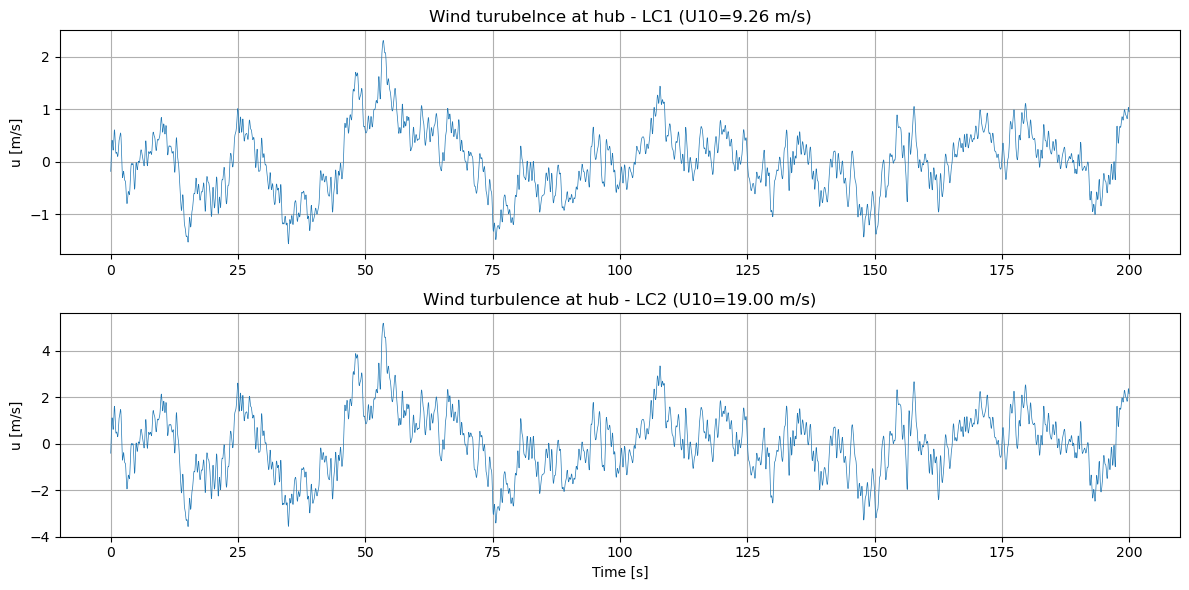

In [88]:
# plot first 200 seconds at hub for both load cases
fig, axes=plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(t[:4000], u_wind_LC1[-1, :4000], linewidth=0.5)
axes[0].set_ylabel('u [m/s]')
axes[0].set_title(f'Wind turubelnce at hub - LC1 (U10={U10_LC1:.2f} m/s)')
axes[0].grid(True)

axes[1].plot(t[:4000], u_wind_LC2[-1, :4000],linewidth=0.5)
axes[1].set_ylabel('u [m/s]')
axes[1].set_title(f'Wind turbulence at hub - LC2 (U10={U10_LC2:.2f} m/s)')
axes[1].set_xlabel('Time [s]')
axes[1].grid(True)

plt.tight_layout()
plt.show()



In [89]:
# ==== WAVE TIME SERIES ======
g=9.81
h=Hw # water depth [m]

# Wave amplitudes from JONSWAP spectrum
domega=omega_axis[1]-omega_axis[0]
A_wave_LC1=np.sqrt(2*S_jonswap_LC1*domega)
A_wave_LC2=np.sqrt(2*S_jonswap_LC2*domega)

# random phase angles for waves
phi_wave_LC1=np.random.uniform(0,2*np.pi, len(omega_axis))
phi_wave_LC2=np.random.uniform(0,2*np.pi, len(omega_axis))

# solve dispersion relation for wave numbers
from dynamics_tools import wave_numbers
k_arr_LC1= wave_numbers(omega_axis, h)
k_arr_LC2= wave_numbers(omega_axis, h)

print(f"k_arr_LC2 range: {k_arr_LC1[0]:.6f} to {k_arr_LC1[-1]:.4f} rad/m")
print(f"k*h range LC1: {k_arr_LC1[0]*h:.6f} to {k_arr_LC1[-1]*h:.4f}")
print(f"sinh(k*h) min LC1: {np.min(np.sinh(k_arr_LC1*h)):.6f}")



k_arr_LC2 range: 0.003352 to 23.6520 rad/m
k*h range LC1: 0.120655 to 851.4712
sinh(k*h) min LC1: 0.120948


C:\Users\gabri\AppData\Local\Temp\ipykernel_23860\3147449354.py:21: RuntimeWarning: overflow encountered in sinh
  print(f"sinh(k*h) min LC1: {np.min(np.sinh(k_arr_LC1*h)):.6f}")


In [90]:
# surface elevation time series
eta_LC1=np.zeros(N_t)
eta_LC2=np.zeros(N_t)

for k, omk in enumerate(omega_axis):
    eta_LC1 += A_wave_LC1[k]*np.cos(omk*t+phi_wave_LC1[k])
    eta_LC2 += A_wave_LC2[k]*np.cos(omk*t+phi_wave_LC2[k])

print(f"\n Wave Time Series")
print(f"LC1 Hs estimate (4*std): {4*np.std(eta_LC1):.3f} m (target: {Hs_LC1:.3f} m )")
print(f"LC2 Hs estimate (4*std): {4*np.std(eta_LC2):.3f} m (target: {Hs_LC2:.3f} m )")

Hs_check_LC1=4*np.sqrt(np.sum(S_jonswap_LC1*domega))
Hs_check_LC2=4*np.sqrt(np.sum(S_jonswap_LC2*domega))
print(f"Hs from spectrum LC1: {Hs_check_LC1:.3f} m")
print(f"Hs from spectrum LC2: {Hs_check_LC2:.3f} m")




 Wave Time Series
LC1 Hs estimate (4*std): 2.008 m (target: 2.008 m )
LC2 Hs estimate (4*std): 4.199 m (target: 4.118 m )
Hs from spectrum LC1: 2.008 m
Hs from spectrum LC2: 4.118 m


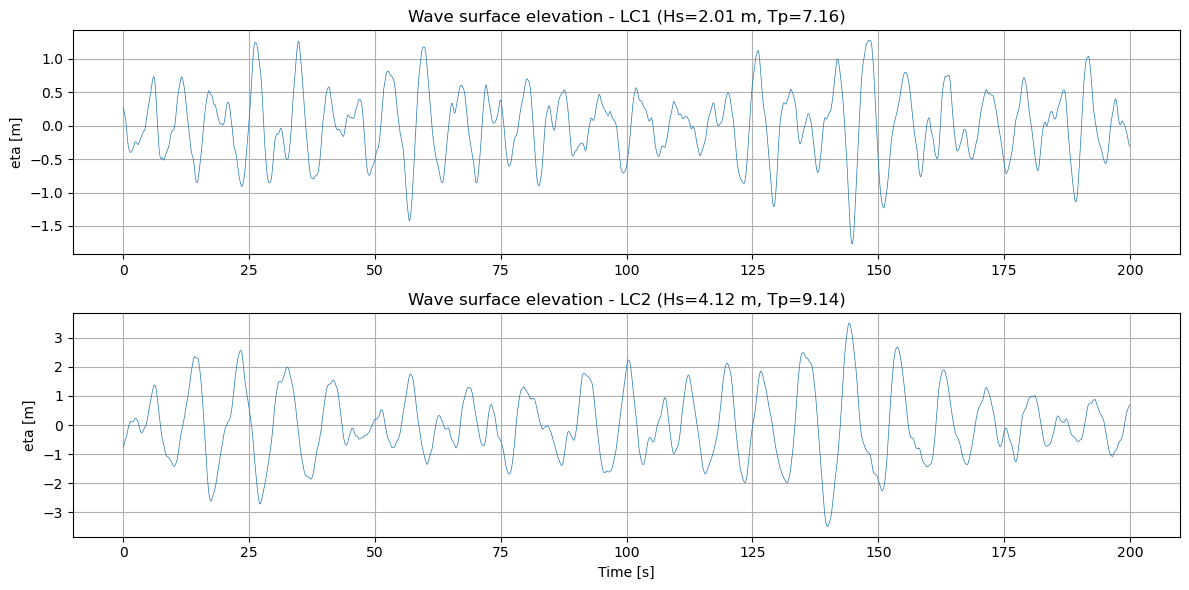

In [91]:
# plot first 200 seconds
fig, axes=plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(t[:4000], eta_LC1[:4000], linewidth=0.5)
axes[0].set_ylabel('eta [m]')
axes[0].set_title(f'Wave surface elevation - LC1 (Hs={Hs_LC1:.2f} m, Tp={Tp_LC1:.2f})')
axes[0].grid(True)

axes[1].plot(t[:4000], eta_LC2[:4000], linewidth=0.5)
axes[1].set_ylabel('eta [m]')
axes[1].set_title(f'Wave surface elevation - LC2 (Hs={Hs_LC2:.2f} m, Tp={Tp_LC2:.2f})')
axes[1].set_xlabel('Time [s]')
axes[1].grid(True)

plt.tight_layout()
plt.show()



In [92]:
# ===== WATER PARTICLE KINEMATICS =====
# submerged node heights above seabed
z_sub_nodes=z_nodes[:elem_w+1] # nodes from mudline to waterline
n_sub=len(z_sub_nodes)

# particle velocity and acceleration at each submerged node
# shape: (n_sub, N_t)
u_water_LC1=np.zeros((n_sub, N_t))
du_water_LC1=np.zeros((n_sub, N_t))
u_water_LC2=np.zeros((n_sub, N_t))
du_water_LC2=np.zeros((n_sub, N_t))

for i, zi in enumerate(z_sub_nodes):
    z_from_surface=zi-h #convrty: 0 at mudline -> -h, h at surface -> 0
    kh_LC1=k_arr_LC1*h
    kh_LC2=k_arr_LC2*h

    # use deep water approximation where kh is large to avoid overflow
    # cosh(k(z+h))/sinh(kh) -> exp(k*z) for large kh
    
    
    depth_factor_LC1=np.where(
        kh_LC1< 50,
        np.cosh(k_arr_LC1*(z_from_surface+h))/np.sinh(kh_LC1),
        np.exp(k_arr_LC1*z_from_surface)
    )
    depth_factor_LC2=np.where(
        kh_LC2 < 50,
        np.cosh(k_arr_LC2*(z_from_surface+h))/np.sinh(kh_LC2),
        np.exp(k_arr_LC2*z_from_surface)
    )
    for k, omk in enumerate(omega_axis):
        #velocity
        u_water_LC1[i,:] += A_wave_LC1[k]*omk*depth_factor_LC1[k]*\
                             np.cos(omk*t+phi_wave_LC1[k])
        u_water_LC2[i,:] += A_wave_LC2[k]*omk*depth_factor_LC2[k]*\
                             np.cos(omk*t+phi_wave_LC2[k])
        # acceleration 
        du_water_LC1[i,:] += -A_wave_LC1[k]*omk**2*depth_factor_LC1[k]*\
                             np.sin(omk*t+phi_wave_LC1[k])
        du_water_LC2[i,:] += -A_wave_LC2[k]*omk**2*depth_factor_LC2[k]*\
                             np.sin(omk*t+phi_wave_LC2[k])
        
print(f"\n Water Particle Kinematics")
print(f" LC1 max velocity at surface: {np.max(abs(u_water_LC1[-1,:])):.3f} m/s")
print(f" LC2 max velocity at surface: {np.max(abs(u_water_LC2[-1,:])):.3f} m/s")
print(f"LC1 max velocity at mudline: {np.max(abs(u_water_LC1[0,:])):.3f} m/s")
print(f"LC2 max velocity at mudline: {np.max(abs(u_water_LC2[0,:])):.3f} m/s")



C:\Users\gabri\AppData\Local\Temp\ipykernel_23860\1176758322.py:24: RuntimeWarning: overflow encountered in sinh
  np.cosh(k_arr_LC1*(z_from_surface+h))/np.sinh(kh_LC1),
C:\Users\gabri\AppData\Local\Temp\ipykernel_23860\1176758322.py:29: RuntimeWarning: overflow encountered in sinh
  np.cosh(k_arr_LC2*(z_from_surface+h))/np.sinh(kh_LC2),
C:\Users\gabri\AppData\Local\Temp\ipykernel_23860\1176758322.py:24: RuntimeWarning: overflow encountered in cosh
  np.cosh(k_arr_LC1*(z_from_surface+h))/np.sinh(kh_LC1),
C:\Users\gabri\AppData\Local\Temp\ipykernel_23860\1176758322.py:24: RuntimeWarning: invalid value encountered in divide
  np.cosh(k_arr_LC1*(z_from_surface+h))/np.sinh(kh_LC1),
C:\Users\gabri\AppData\Local\Temp\ipykernel_23860\1176758322.py:29: RuntimeWarning: overflow encountered in cosh
  np.cosh(k_arr_LC2*(z_from_surface+h))/np.sinh(kh_LC2),
C:\Users\gabri\AppData\Local\Temp\ipykernel_23860\1176758322.py:29: RuntimeWarning: invalid value encountered in divide
  np.cosh(k_arr_LC2*(z_


 Water Particle Kinematics
 LC1 max velocity at surface: 2.233 m/s
 LC2 max velocity at surface: 3.293 m/s
LC1 max velocity at mudline: 0.153 m/s
LC2 max velocity at mudline: 0.723 m/s


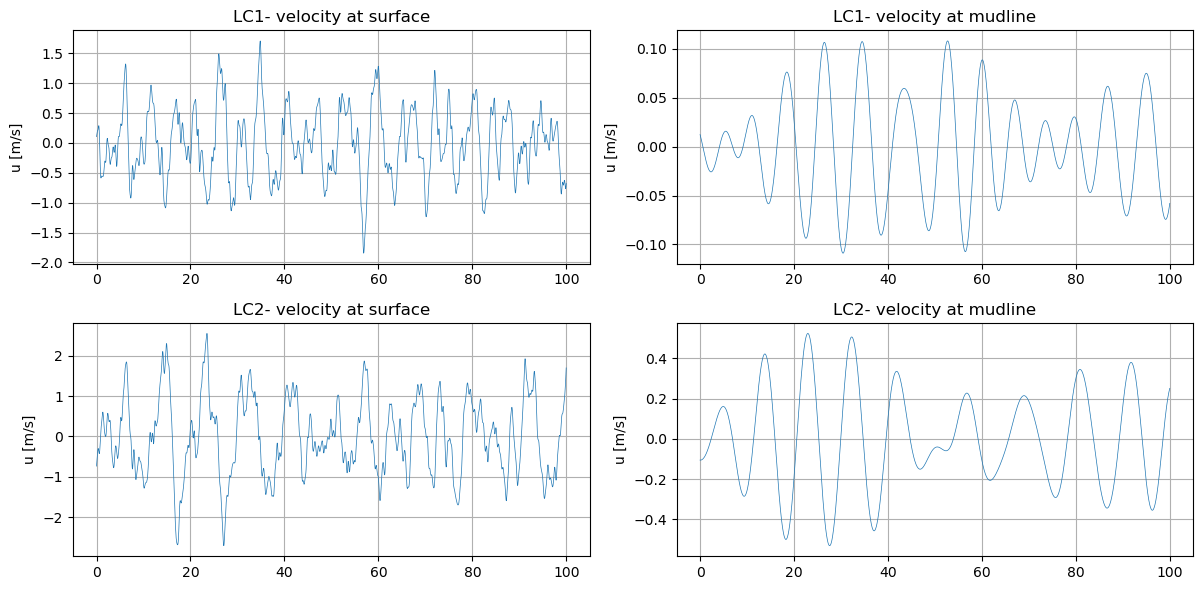

In [93]:
# plot velocity at surface and mudline
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

axes[0,0].plot(t[:2000], u_water_LC1[-1, :2000], linewidth=0.5)
axes[0,0].set_ylabel('u [m/s]')
axes[0,0].set_title('LC1- velocity at surface')
axes[0,0].grid(True)

axes[0,1].plot(t[:2000], u_water_LC1[0, :2000], linewidth=0.5)
axes[0,1].set_ylabel('u [m/s]')
axes[0,1].set_title('LC1- velocity at mudline')
axes[0,1].grid(True)

axes[1,0].plot(t[:2000], u_water_LC2[-1, :2000], linewidth=0.5)
axes[1,0].set_ylabel('u [m/s]')
axes[1,0].set_title('LC2- velocity at surface')
axes[1,0].grid(True)

axes[1,1].plot(t[:2000], u_water_LC2[0, :2000], linewidth=0.5)
axes[1,1].set_ylabel('u [m/s]')
axes[1,1].set_title('LC2- velocity at mudline')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()



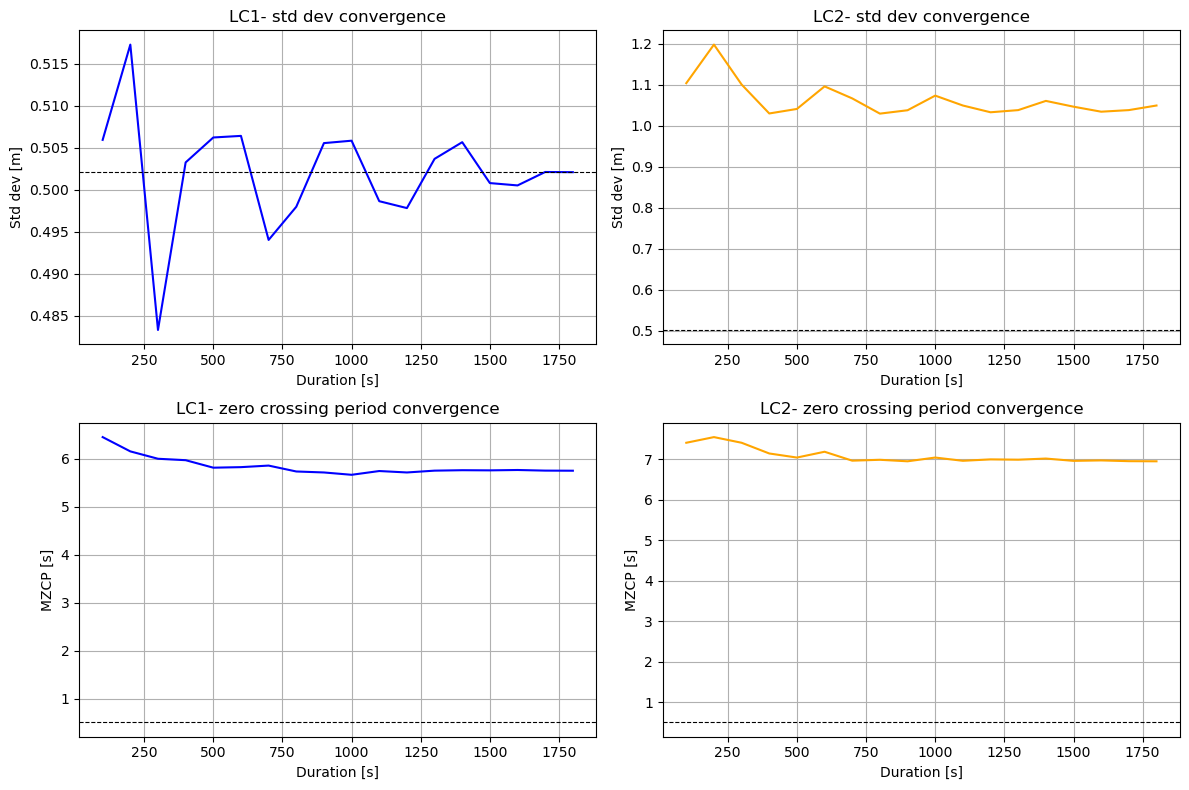


 Convergence Analysis
Final std LC1: 0.5021 m
Final std LC2: 1.0499 m
Final MZCP LC1: 5.75 s (Tp=7.16 s)
Final MZCP LC2: 5.75 s (Tp=9.14 s)


In [94]:
# ==== CONVERGENCE ANALYSIS =====
#progressively increase duration and monitor std dev and mean zero crossing period
T_lengths=np.arange(100, T_total+1, 100) # 100 to 1800 s in steps of 100

std_LC1=np.zeros(len(T_lengths))
std_LC2=np.zeros(len(T_lengths))
mzcp_LC1=np.zeros(len(T_lengths))
mzcp_LC2=np.zeros(len(T_lengths))

def mean_zero_crossing_period(signal, dt):
    # count zero crossings
    zero_crossings=np.where(np.diff(np.sign(signal)))[0]
    if len(zero_crossings) < 2:
        return np.nan
    return 2*len(signal)*dt/len(zero_crossings)

for j, T_len in enumerate(T_lengths):
    N_len=int(T_len/dt)
    # use surface elevation as the convergence signal
    std_LC1[j] =np.std(eta_LC1[:N_len])
    std_LC2[j]=np.std(eta_LC2[:N_len])
    mzcp_LC1[j]=mean_zero_crossing_period(eta_LC1[:N_len], dt)
    mzcp_LC2[j]=mean_zero_crossing_period(eta_LC2[:N_len], dt)
fig, axes=plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(T_lengths, std_LC1, 'b')
axes[0,0].axhline(np.std(eta_LC1), color='k', linestyle='--', linewidth=0.8)
axes[0,0].set_xlabel('Duration [s]')
axes[0,0].set_ylabel('Std dev [m]')
axes[0,0].set_title('LC1- std dev convergence')
axes[0,0].grid(True)

axes[0,1].plot(T_lengths, std_LC2, 'orange')
axes[0,1].axhline(np.std(eta_LC1), color='k', linestyle='--', linewidth=0.8)
axes[0,1].set_xlabel('Duration [s]')
axes[0,1].set_ylabel('Std dev [m]')
axes[0,1].set_title('LC2- std dev convergence')
axes[0,1].grid(True)

axes[1,0].plot(T_lengths, mzcp_LC1, 'b')
axes[1,0].axhline(np.std(eta_LC1), color='k', linestyle='--', linewidth=0.8)
axes[1,0].set_xlabel('Duration [s]')
axes[1,0].set_ylabel('MZCP [s]')
axes[1,0].set_title('LC1- zero crossing period convergence')
axes[1,0].grid(True)

axes[1,1].plot(T_lengths, mzcp_LC2, 'orange')
axes[1,1].axhline(np.std(eta_LC1), color='k', linestyle='--', linewidth=0.8)
axes[1,1].set_xlabel('Duration [s]')
axes[1,1].set_ylabel('MZCP [s]')
axes[1,1].set_title('LC2- zero crossing period convergence')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

print(f"\n Convergence Analysis")
print( f"Final std LC1: {std_LC1[-1]:.4f} m")
print( f"Final std LC2: {std_LC2[-1]:.4f} m")
print( f"Final MZCP LC1: {mzcp_LC1[-1]:.2f} s (Tp={Tp_LC1:.2f} s)")
print( f"Final MZCP LC2: {mzcp_LC1[-1]:.2f} s (Tp={Tp_LC2:.2f} s)")



In [95]:
# ==== SAVE OUTPUTS ======
output_dir = NOTEBOOK_DIR / 'outputs'
output_dir.mkdir(parents=True, exist_ok=True)

np.savez(output_dir / 'timeseries_results.npz',
    t=t,
    dt=np.array([dt]),
    T_total=np.array([T_total]),

    #wind
    u_wind_LC1=u_wind_LC1,
    u_wind_LC2=u_wind_LC2,
    #waves
    eta_LC1=eta_LC1,
    eta_LC2=eta_LC2,
    #water kinematics
    u_water_LC1=u_water_LC1,
    du_water_LC1=du_water_LC1,
    u_water_LC2=u_water_LC2,
    du_water_LC2=du_water_LC2,
    z_sub_nodes=z_sub_nodes
)
print("\nTime series results saved to outputs/timeseries_results.npz")


Time series results saved to outputs/timeseries_results.npz


## WW_step5_frequency.ipynb


In [96]:
# ================================================
# CIEM5220 - Wave and Wind loads
#     Waterbound Windturbine 
#       STEP 5 - FREQUENCY
# ================================================

import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
for parent in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    candidate = parent / "CIEM5220" / "Windturbine"
    if (candidate / "dynamics_tools.py").exists():
        NOTEBOOK_DIR = candidate
        break

sys.path.insert(0, str(NOTEBOOK_DIR))

import numpy as np
import matplotlib.pyplot as plt



In [97]:
#==== LOAD FEM RESULTS =====
fem=np.load(NOTEBOOK_DIR / 'outputs' / 'fem_results.npz')

freq =fem['freq']
omega=fem['omega']
eigenvectors=fem['eigenvectors']
K_free= fem['K_free']
M_free= fem['M_free']
C_free=fem['C_free']
D0 = float(fem['D0'])
le=float(fem['le'])
Hw=float(fem['Hw'])
Ha= float(fem['Ha'])
L=float(fem['L'])
elem_w=int(fem['elem_w'])
elem_a=int(fem['elem_a'])
ndof=int(fem['ndof'])
EI=float(fem['EI'])

elements=elem_w+elem_a
nodes=elements+1
f1=freq[0]
f2=freq[1]



In [98]:
# ===== LOAD SPECTRA RESULTS ======
spec=np.load(NOTEBOOK_DIR / 'outputs' / 'spectra_results.npz')

f_axis=spec['f_axis']
omega_axis=spec['omega_axis']
S_kaimal_LC1=spec['S_kaimal_LC1']
S_kaimal_LC2=spec['S_kaimal_LC2']
S_co_LC1=spec['S_co_LC1']
S_co_LC2=spec['S_co_LC2']
S_jonswap_LC1=spec['S_jonswap_LC1']
S_jonswap_LC2=spec['S_jonswap_LC2']
omega_p_LC1=float(spec['omega_p_LC1'])
omega_p_LC2=float(spec['omega_p_LC2'])
Hs_LC1=float(spec['Hs_LC1'])
Hs_LC2=float(spec['Hs_LC2'])
Tp_LC1=float(spec['Tp_LC1'])
Tp_LC2=float(spec['Tp_LC2'])
U_mean_LC1=spec['U_mean_LC1']
U_mean_LC2=spec['U_mean_LC2']
z_nodes=spec['z_nodes']
z_above=spec['z_above']
air_nodes=spec['air_nodes']

print(f"Loaded FEM and spectra results")
print(f"f1={f1:.4f} Hz, f2={f2:.4f} Hz")
print(f"ndof={ndof}, elem_w={elem_w}, elem_a={elem_a}")



Loaded FEM and spectra results
f1=0.1397 Hz, f2=1.2122 Hz
ndof=26, elem_w=3, elem_a=9


C:\Users\gabri\AppData\Local\Temp\ipykernel_23860\713428033.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  omega_p_LC1=float(spec['omega_p_LC1'])
C:\Users\gabri\AppData\Local\Temp\ipykernel_23860\713428033.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  omega_p_LC2=float(spec['omega_p_LC2'])
C:\Users\gabri\AppData\Local\Temp\ipykernel_23860\713428033.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Hs_LC1=float(spec['Hs_LC1'])
C:\Users\gabri\AppData\

In [99]:
# ==== FREQUENCY RESPONSE FUNCTION =====
# For each frewuency omega, solve:
#(-omega^2*M+i*omega*C+K)*U=F
# The FRF H(omega) relates nodal force to mudline moment

N_freq= len(omega_axis)
n_free=K_free.shape[0]



In [100]:
#mudline moment extraction vector
# moment at base = EI* d^2U/dx^2 at x=0 of element 0
# for clamped base this comes from the first free DOFs (nodes 1,2)
# M_mudline= EI*(6/le^2*u1-4/le*theta1-6/le^2*u+2/le*theta0)
#since u+)theta0=0 (clamped):M_mudline=EI*(6/le^2*u1-4/le*theta1)
#in free DOF vector: u1 is index 0, theta1 is index 1

e_moment=np.zeros(n_free)
e_moment[0]=EI*6/le**2 # coefficient for u1
e_moment[1]=EI*(-4)/le # coefficient for theta1



In [101]:
# frequency response function: H[node, freq]=mudline moment per unit force at node
H_moment=np.zeros((n_free, N_freq), dtype=complex)

for k, omk in enumerate(omega_axis):
    # dynamic stiffness matrix
    Z=(-omk**2*M_free+1j*omk*C_free+K_free)
    # solve for each unit force applied at each free DOF
    # columns of Z_inv give displacement per unit force
    Z_inv=np.linalg.solve(Z, np.eye(n_free))
    # mudline moment= e_moment @ Z_inv @ f
    H_moment[:, k]=e_moment @ Z_inv

print(f"\n Frequency Response Function")
print(f"H_moment shape: {H_moment.shape}")
print(f"Peak response at f1: {np.max(np.abs(H_moment)):.3e} Nm/N")




 Frequency Response Function
H_moment shape: (24, 1000)
Peak response at f1: 3.255e+03 Nm/N


In [102]:
# ==== WIND FORCE SPECTRUM =====
# linearised drag force per unit length: dF/dz=rho_air*Cd*D*U_mean*Su(f)
rho_air=1.25 # [kg/m^3]
Cd_wind=0.8 # drag coefficient for cylinder

# force spectrum at each air node
# S_F= (rho_air*Cd*D*U_mean)^2*S_u
n_air=len(air_nodes)

S_Fwind_LC1=np.zeros((n_air, N_freq))
S_Fwind_LC2=np.zeros((n_air, N_freq))

for i, node in enumerate(air_nodes):
    coeff_LC1=(rho_air*Cd_wind*D0*U_mean_LC1[node])**2
    coeff_LC2=(rho_air*Cd_wind*D0*U_mean_LC1[node])**2
    S_Fwind_LC1[i, :]=coeff_LC1*S_kaimal_LC1[i,:]
    S_Fwind_LC2[i, :]=coeff_LC1*S_kaimal_LC2[i,:]



In [103]:
# ==== WAVE FORCE SPECTRUM ======
# linearised Morison: dF/dz= rho_w*Cm*pi*D^2/4*du/dt (inertia)
#.                          + rho_w*Cd*D*u_rms*u (linearised drag)

rho_w=1025.0 # [kg/m^3]
Cm=2 # inertia coefficient
Cd_wave=1 # drag coefficient



In [104]:
# Wave number at each frequency
from dynamics_tools import wave_numbers

h= Hw
k_arr = wave_numbers(omega_axis, h)

# depth factor at each submerged node
z_sub_nodes=z_nodes[:elem_w+1]
n_sub=len(z_sub_nodes)

S_Fwave_LC1=np.zeros((n_sub, N_freq))
S_Fwave_LC2=np.zeros((n_sub, N_freq))

domega=omega_axis[1]-omega_axis[0]

for i, zi in enumerate(z_sub_nodes):
    z_from_surface=zi-h
    kh=k_arr*h
    depth_factor=np.where(
        kh<50, 
        np.cosh(k_arr*(z_from_surface+h))/np.sinh(kh),
        np.exp(k_arr*z_from_surface)
    )
    # inertia term transfer function
    H_inertia=rho_w*Cm*np.pi*D0**2/4*omega_axis*depth_factor
    # drag term - linearised using rms velocity
    u_rms_LC1= np.sqrt(np.sum(S_jonswap_LC1*omega_axis**2*depth_factor**2*domega))
    u_rms_LC2= np.sqrt(np.sum(S_jonswap_LC2*omega_axis**2*depth_factor**2*domega))
    H_drag_LC1=rho_w*Cd_wave*D0*u_rms_LC1*depth_factor
    H_drag_LC2=rho_w*Cd_wave*D0*u_rms_LC2*depth_factor

    S_Fwave_LC1[i,:]=(H_inertia + H_drag_LC1)**2*S_jonswap_LC1
    S_Fwave_LC2[i,:]=(H_inertia + H_drag_LC2)**2*S_jonswap_LC2

print(f"n Force Spectra")
print(f"Max wind force PSD LC1: {np.max(S_Fwind_LC1):.3e} N^2/Hz")
print(f"Max wind force PSD LC2: {np.max(S_Fwind_LC2):.3e} N^2/Hz")
print(f"Max wave force PSD LC1: {np.max(S_Fwave_LC1):.3e} N^2/Hz")
print(f"Max wave force PSD LC2: {np.max(S_Fwave_LC2):.3e} N^2/Hz")



n Force Spectra
Max wind force PSD LC1: 3.736e+04 N^2/Hz
Max wind force PSD LC2: 1.228e+05 N^2/Hz
Max wave force PSD LC1: 1.556e+09 N^2/Hz
Max wave force PSD LC2: 6.475e+09 N^2/Hz


C:\Users\gabri\AppData\Local\Temp\ipykernel_23860\1998090492.py:21: RuntimeWarning: overflow encountered in sinh
  np.cosh(k_arr*(z_from_surface+h))/np.sinh(kh),
C:\Users\gabri\AppData\Local\Temp\ipykernel_23860\1998090492.py:21: RuntimeWarning: overflow encountered in cosh
  np.cosh(k_arr*(z_from_surface+h))/np.sinh(kh),
C:\Users\gabri\AppData\Local\Temp\ipykernel_23860\1998090492.py:21: RuntimeWarning: invalid value encountered in divide
  np.cosh(k_arr*(z_from_surface+h))/np.sinh(kh),


In [105]:
# ===== MUDLINE MOMENT SPECTRUM =====
# S_MM(omega)=sum over all nodes of |H_node(omega)|^2*S_F_node(omega)
# plus cross terms from co-spectra for wind

S_MM_wind_LC1=np.zeros(N_freq)
S_MM_wind_LC2=np.zeros(N_freq)
S_MM_wave_LC1=np.zeros(N_freq)
S_MM_wave_LC2=np.zeros(N_freq)

# wind contribution - includes co-spectrum cross terms
for i in range (n_air):
    dof_i=2*(elem_w+i) # lateral DOF of this air node in free system
    fi=dof_i-2 # index in free DOF vector
    for j in range(n_air):
        dof_j=2*(elem_w+j)
        fj=dof_j-2
        S_MM_wind_LC1+= (np.abs(H_moment[fi])*
                         np.abs(H_moment[fj])*
                         S_co_LC1[i,j,:])
        S_MM_wind_LC2+= (np.abs(H_moment[fi])*
                         np.abs(H_moment[fj])*
                         S_co_LC2[i,j,:])
        
#wave contribution - nodes are uncorrelated so no cross terms
for i in range(n_sub):
    dof_i=2*i # lateral DOF of submerged node
    fi=dof_i-2 # index in free DOF vector
    if fi<0:
        continue # skip clamped base node
    S_MM_wave_LC1 += np.abs(H_moment[fi])**2*S_Fwave_LC1[i, :]
    S_MM_wave_LC2 += np.abs(H_moment[fi])**2*S_Fwave_LC2[i, :]

# total moment spectrum
S_MM_LC1=S_MM_wind_LC1+S_MM_wave_LC1
S_MM_LC2=S_MM_wind_LC2+S_MM_wave_LC2

print(f"\n Mudline Moment Spectrum")
print(f"std LC1 (wave): {np.sqrt(np.trapz(S_MM_wave_LC1, omega_axis))/1e6:.3f} MNm")
print(f"std LC1 (wind): {np.sqrt(np.trapz(S_MM_wind_LC1, omega_axis))/1e6:.3f} MNm")
print(f"std LC1 (total): {np.sqrt(np.trapz(S_MM_LC1, omega_axis))/1e6:.3f} MNm")
print(f"std LC2 (wave): {np.sqrt(np.trapz(S_MM_wave_LC2, omega_axis))/1e6:.3f} MNm")
print(f"std LC2 (wind): {np.sqrt(np.trapz(S_MM_wind_LC2, omega_axis))/1e6:.3f} MNm")
print(f"std LC2 (total): {np.sqrt(np.trapz(S_MM_LC2, omega_axis))/1e6:.3f} MNm")




 Mudline Moment Spectrum
std LC1 (wave): 2.601 MNm
std LC1 (wind): 0.001 MNm
std LC1 (total): 2.601 MNm
std LC2 (wave): 3.308 MNm
std LC2 (wind): 0.003 MNm
std LC2 (total): 3.308 MNm


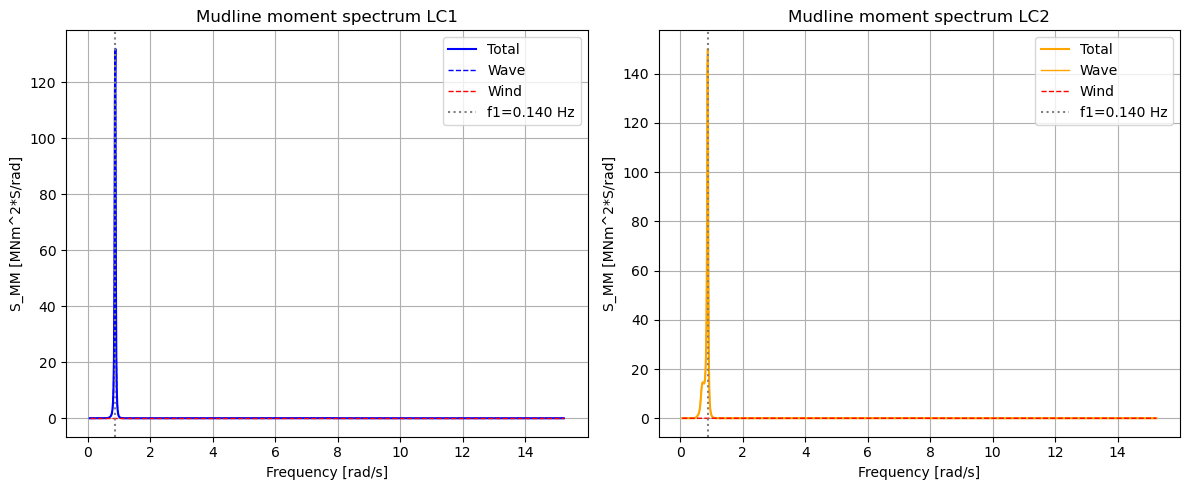

S_MM at f1 LC1: 132.01 MNm^2s/rad
S_MM at f1 LC2: 150.08 MNm^2s/rad


In [106]:
#======= PLOT MUDLINE MOMENT SPECTRUM =======

fig, axes= plt.subplots(1,2,figsize=(12,5))

axes[0].plot(omega_axis, S_MM_LC1/1e12, 'b', linewidth=1.5, label='Total')
axes[0].plot(omega_axis, S_MM_wave_LC1/1e12, 'b--', linewidth=1, label='Wave')
axes[0].plot(omega_axis, S_MM_wind_LC1/1e12, 'r--', linewidth=1, label='Wind')
axes[0].axvline(2*np.pi*f1, color='gray', linestyle=':', label=f'f1={f1:.3f} Hz')
axes[0].set_xlabel('Frequency [rad/s]')
axes[0].set_ylabel('S_MM [MNm^2*S/rad]')
axes[0].set_title('Mudline moment spectrum LC1')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(omega_axis, S_MM_LC2/1e12, 'orange', linewidth=1.5, label='Total')
axes[1].plot(omega_axis, S_MM_wave_LC2/1e12, 'orange', linewidth=1, label='Wave')
axes[1].plot(omega_axis, S_MM_wind_LC2/1e12, 'r--', linewidth=1, label='Wind')
axes[1].axvline(2*np.pi*f1, color='gray', linestyle=':', label=f'f1={f1:.3f} Hz')
axes[1].set_xlabel('Frequency [rad/s]')
axes[1].set_ylabel('S_MM [MNm^2*S/rad]')
axes[1].set_title('Mudline moment spectrum LC2')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

idx_f1=np.argmin(np.abs(omega_axis-2*np.pi*f1))
print(f"S_MM at f1 LC1: {S_MM_LC1[idx_f1]/1e12:.2f} MNm^2s/rad")
print(f"S_MM at f1 LC2: {S_MM_LC2[idx_f1]/1e12:.2f} MNm^2s/rad")



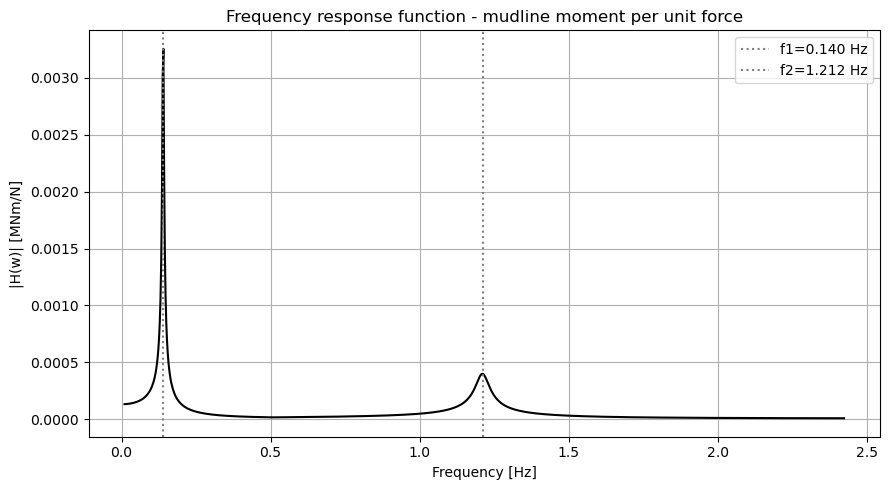

In [107]:
# ===== PLOT FRF =========
fig, ax=plt.subplots(figsize=(9,5))
ax.plot(omega_axis/(2*np.pi), np.max(np.abs(H_moment), axis=0)/1e6,
        'k', linewidth=1.5)
ax.axvline(f1, color='gray', linestyle=':', label=f'f1={f1:.3f} Hz')
ax.axvline(f2, color='gray', linestyle=':', label=f'f2={f2:.3f} Hz')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('|H(w)| [MNm/N]')
ax.set_title('Frequency response function - mudline moment per unit force')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()



In [108]:
# ===== STATISTICAL QUANTITIES =====
# spectral moments
df=omega_axis[1]-omega_axis[0]

def spectral_moment(S, omega, n):
    return np.trapz(omega**n*S, omega)

# LC1
m0_LC1=spectral_moment(S_MM_LC1, omega_axis, 0)
m2_LC1=spectral_moment(S_MM_LC1, omega_axis, 2)
std_LC1=np.sqrt(m0_LC1)
Tz_LC1=2*np.pi*np.sqrt(m0_LC1/m2_LC1) # mean zero crossing period

# LC2
m0_LC2= spectral_moment(S_MM_LC2, omega_axis, 0)
m2_LC2= spectral_moment(S_MM_LC2, omega_axis, 2)
std_LC2=np.sqrt(m0_LC2)
Tz_LC2=2*np.pi*np.sqrt(m0_LC2/m2_LC2) 

print(f"\n Statistical Quantities")
print(f"LC1: std= {std_LC1/1e6:.3f} MNm, Tz= {Tz_LC1:.2f}")
print(f"LC2: std={std_LC2/1e6:.3f} MNm, {Tz_LC2:.2f}")




 Statistical Quantities
LC1: std= 2.601 MNm, Tz= 6.00
LC2: std=3.308 MNm, 6.17


In [109]:
#==== SAVE OUTPUTS =====
output_dir = NOTEBOOK_DIR / 'outputs'
output_dir.mkdir(parents=True, exist_ok=True)

np.savez(output_dir / 'frequency_results.npz',
    omega_axis=omega_axis,
    S_MM_LC1=S_MM_LC1,
    S_MM_LC2=S_MM_LC2,
    S_MM_wave_LC1=S_MM_wave_LC1,
    S_MM_wave_LC2=S_MM_wave_LC2,
    S_MM_wind_LC1=S_MM_wind_LC1,
    S_MM_wind_LC2=S_MM_wind_LC2,
    std_LC1=np.array([std_LC1]),
    std_LC2=np.array([std_LC2]),
    Tz_LC1=np.array([Tz_LC1]),
    Tz_LC2=np.array([Tz_LC2]),
    H_moment=H_moment
)
print("\nFrequency domain results saved to outputs/frequency_results.npz")



Frequency domain results saved to outputs/frequency_results.npz


## WW_step6_timedomain.ipynb


In [110]:
# ================================================
# CIEM5220 - Wave and Wind loads
#     Waterbound Windturbine 
#   STEP 6 - TIME DOMAIN ANALYSIS
# ================================================

import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
for parent in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    candidate = parent / "CIEM5220" / "Windturbine"
    if (candidate / "dynamics_tools.py").exists():
        NOTEBOOK_DIR = candidate
        break

sys.path.insert(0, str(NOTEBOOK_DIR))

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve



In [111]:
#==== LOAD ALL RESULTS =====
fem=np.load(NOTEBOOK_DIR / 'outputs' / 'fem_results.npz')
spec=np.load(NOTEBOOK_DIR / 'outputs' / 'spectra_results.npz')
ts=np.load(NOTEBOOK_DIR / 'outputs' / 'timeseries_results.npz')

# FEM

K_free= fem['K_free']
M_free= fem['M_free']
C_free=fem['C_free']
EI=float(fem['EI'])
D0 = float(fem['D0'])
le=float(fem['le'])
Hw=float(fem['Hw'])
Ha= float(fem['Ha'])
L=float(fem['L'])
elem_w=int(fem['elem_w'])
elem_a=int(fem['elem_a'])
ndof=int(fem['ndof'])

elements=elem_w+elem_a
nodes=elements+1
freq =fem['freq']
f1=freq[0]
f2=freq[1]

n_free=K_free.shape[0]

# Time series

t=ts['t']
dt=float(ts['dt'])

u_wind_LC1=ts['u_wind_LC1']
u_wind_LC2=ts['u_wind_LC2']

u_water_LC1=ts['u_water_LC1']
du_water_LC1=ts['du_water_LC1']
u_water_LC2=ts['u_water_LC2']
du_water_LC2=ts['du_water_LC2']
z_sub_nodes=ts['z_sub_nodes']

# Spectra

U_mean_LC1=spec['U_mean_LC1']
U_mean_LC2=spec['U_mean_LC2']
z_nodes=spec['z_nodes']
z_above=spec['z_above']
air_nodes=spec['air_nodes']

N_t=len(t)
n_sub=len(z_sub_nodes)
n_air=len(air_nodes)

print(f"Loaded all results")
print(f"N_t={N_t}, dt={dt} s, T={t[-1]:.0f} s")



Loaded all results
N_t=36000, dt=0.05 s, T=1800 s


C:\Users\gabri\AppData\Local\Temp\ipykernel_23860\143864357.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dt=float(ts['dt'])


In [112]:
# ==== PARAMETERS =======
rho_w=1025.0 # seawater density [kg/m^3]
rho_air=1.25 # air density [kg/m^3]
Cm=2.0 # inertia coefficient
Cd_wave=1.0 # wave drag coefficient
Cd_wind=0.8 # wind drag coefficient

# mudline moment extraction
e_moment=np.zeros(n_free)
e_moment[0]=EI*6/le**2
e_moment[1]=EI*(-4)/le

# Newmark-beta integration parameters
gamma_nm=0.5
beta_nm=0.25 # constant average acceleration - unconditionally stable

# ==== TIME DOMAIN INTREGRATION =====
def compute_forces(v_full, u_water, du_water, 
                   u_wind, U_mean, step,
                   Cd_wave_local=None, Cd_wind_local=None):
    if Cd_wave_local is None:
        Cd_wave_local = Cd_wave
    if Cd_wind_local is None:
        Cd_wind_local = Cd_wind

    f=np.zeros(ndof)
    
    # wave forces on submerged nodes
    for e in range(elem_w):
        node_bot=e
        node_top=e+1
        dof_bot=2*node_bot
        dof_top=2*node_top
       
        # average kinematics over element
        u_w_avg=0.5*(u_water[node_bot, step]+u_water[node_top, step])
        du_w_avg=0.5*(du_water[node_bot, step]+ du_water[node_top, step])

        # structural velocity at this node
        v_struct=v_full[dof_top] if dof_top < len(v_full) else 0.0
        
        u_rel=u_w_avg-v_struct
        F_iner=rho_w*Cm*np.pi*D0**2/4*du_w_avg
        F_drag=0.5*rho_w*Cd_wave_local*D0*u_rel*abs(u_rel)
        F_total=(F_iner+F_drag)*le

        # distribute equally to both nodes
        f[dof_bot]+=F_total/2
        f[dof_top]+=F_total/2

    # wind forces on air nodes
    for i, node in enumerate(air_nodes):
        dof=2*node
        u_w=u_wind[i, step]
        U_tot=U_mean[node]+u_w
        F_wind=0.5*rho_air*Cd_wind_local*D0*U_tot*abs(U_tot)
        f[dof]+=F_wind*le

    return f

# effective stiffness matrix (constant for linear system)
K_eff=K_free+gamma_nm/(beta_nm*dt)*C_free+1/(beta_nm*dt**2)*M_free

print(f"\n Time integration Setup")
print(f"Newmark-beta: gamma={gamma_nm}, beta={beta_nm}")
print(f"K_eff assembled")




 Time integration Setup
Newmark-beta: gamma=0.5, beta=0.25
K_eff assembled


In [113]:
# initialise
v_full=np.zeros(ndof)
a_full=np.zeros(ndof)

# storage for mudline moment
M_mudline_LC1=np.zeros(N_t)
M_mudline_LC2=np.zeros(N_t)

print(f"\n Running LC1 time integration")




 Running LC1 time integration


In [114]:
u_LC1=np.zeros(n_free)
v_LC1=np.zeros(n_free)
a_LC1=np.zeros(n_free)

for step in range(N_t):
    # external force at this step
    f_ext = compute_forces(v_full, u_water_LC1,
                           du_water_LC1, u_wind_LC1,
                           U_mean_LC1, step)
    f_free=f_ext[2:] # apply boundary conditions

    # effective force
    f_eff=(f_free
            +M_free @ (1/(beta_nm*dt**2)*u_LC1
                      +1/(beta_nm*dt)*v_LC1
                      +(1/(2*beta_nm)-1)*a_LC1)
            +C_free @ (gamma_nm/(beta_nm*dt)*u_LC1
                       -(1-gamma_nm/beta_nm)*v_LC1
                       -dt*(1-gamma_nm/(2*beta_nm))*a_LC1))
    # solve for displacement
    u_new=solve(K_eff, f_eff)

    # update velocity and acceleration
    a_new=(1/(beta_nm*dt**2)*(u_new-u_LC1)
           -1/(beta_nm*dt)*v_LC1
           -(1/(2*beta_nm)-1)*a_LC1)
    v_new=(v_LC1+dt*((1-gamma_nm)*a_LC1+gamma_nm*a_new))

    # extract mudline moment
    M_mudline_LC1[step]=e_moment @ u_new

    # update for next step
    u_LC1=u_new
    v_LC1=v_new
    a_LC1=a_new
    # update full vector for force computation
    v_full[2:]=v_LC1

    if step % 5000==0:
        print(f" step {step}/{N_t}")

print(f"LC1 done. std= {np.std(M_mudline_LC1)/1e6:.3f} MNm")

print(f"\n Running LC2 time integration")



 step 0/36000
 step 5000/36000
 step 10000/36000
 step 15000/36000
 step 20000/36000
 step 25000/36000
 step 30000/36000
 step 35000/36000
LC1 done. std= 15.918 MNm

 Running LC2 time integration


In [115]:
u_LC2=np.zeros(n_free)
v_LC2=np.zeros(n_free)
a_LC2=np.zeros(n_free)
v_full=np.zeros(ndof)

for step in range(N_t):
    # external force at this step
    f_ext = compute_forces(v_full, u_water_LC2,
                           du_water_LC2, u_wind_LC2,
                           U_mean_LC2, step)
    f_free=f_ext[2:] # apply boundary conditions

    # effective force
    f_eff=(f_free
            +M_free @ (1/(beta_nm*dt**2)*u_LC2
                      +1/(beta_nm*dt)*v_LC2
                      +(1/(2*beta_nm)-1)*a_LC2)
            +C_free @ (gamma_nm/(beta_nm*dt)*u_LC2
                       -(1-gamma_nm/beta_nm)*v_LC2
                       -dt*(1-gamma_nm/(2*beta_nm))*a_LC2))
    # solve for displacement
    u_new=solve(K_eff, f_eff)

    # update velocity and acceleration
    a_new=(1/(beta_nm*dt**2)*(u_new-u_LC2)
           -1/(beta_nm*dt)*v_LC2
           -(1/(2*beta_nm)-1)*a_LC2)
    v_new=(v_LC2+dt*((1-gamma_nm)*a_LC2+gamma_nm*a_new))

    # extract mudline moment
    M_mudline_LC2[step]=e_moment @ u_new

    # update for next step
    u_LC2=u_new
    v_LC2=v_new
    a_LC2=a_new
    # update full vector for force computation
    v_full[2:]=v_LC2

    if step % 5000==0:
        print(f" step {step}/{N_t}")

print(f"LC2 done. std= {np.std(M_mudline_LC2)/1e6:.3f} MNm")

print(f"LC1 std= {np.std(M_mudline_LC1)/1e6:.3f} MNm, LC2 std= {np.std(M_mudline_LC2)/1e6:.3f} MNm ")



 step 0/36000
 step 5000/36000
 step 10000/36000
 step 15000/36000
 step 20000/36000
 step 25000/36000
 step 30000/36000
 step 35000/36000
LC2 done. std= 19.662 MNm
LC1 std= 15.918 MNm, LC2 std= 19.662 MNm 


ValueError: x and y must have same first dimension, but have shapes (200,) and (36000,)

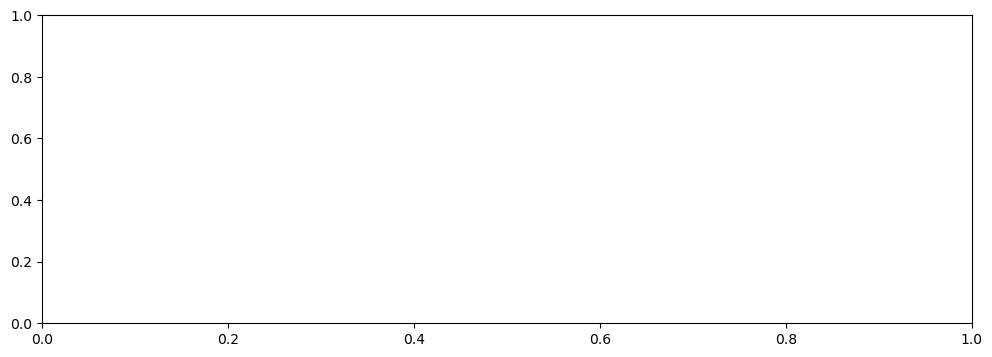

In [ ]:
M_dyn_LC1=M_mudline_LC1-np.mean(M_mudline_LC1)
M_dyn_LC2=M_mudline_LC2-np.mean(M_mudline_LC2)

fig, ax=plt.subplots(figsize=(12, 4))
ax.plot(t, M_mudline_LC1/1e6, linewidth=0.5)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Mudline moment [MNm]')
ax.set_title('Mudline moment time series LC1 - Time domain')
ax.grid(True)
plt.tight_layout()
plt.show()

print(f"Max moment LC1: {np.max(np.abs(M_mudline_LC1))/1e6:.3f} MNm")
print(f"Max moment LC1: {np.mean(M_mudline_LC1)/1e6:.3f} MNm")

print(f"du_water_LC1 at surface, first 10 steps:")
print(du_water_LC1[-1, :10])
print(f"u_water_LC1 at surface, first 10 steps:")
print(u_water_LC1[-1, :10])

omega1=2*np.pi*f1
zeta_check=(e_moment @ C_free @ e_moment)/(2*omega1*(e_moment @ M_free @ e_moment))
print(f"Effective damping ratio: {zeta_check:.4f}")
print(f"C_free max: {np.max(np.abs(C_free)):.3e}")
print(f"M_free max: {np.max(np.abs(M_free)):.3e}")
print(f"K_free max: {np.max(np.abs(K_free)):.3e}")
print(f"omega1: {omega1:.4f} rad/s")



In [117]:
# static moment from mean wind
F_wind_static=np.sum([
    0.5*rho_air*Cd_wind*D0*U_mean_LC1[node]**2*le
    for node in air_nodes
])
# approximate lever arm
z_air=np.mean(z_nodes[air_nodes])
M_static_LC1=F_wind_static*z_air
print(f"Approximate static wind moment LC1: {M_static_LC1/1e6:.2f} MNm")

print(f"le={le} m")
print(f"elem_w={elem_w}")
print(f"n_sub={n_sub}")
print(f"z_sub_nodes={z_sub_nodes}")


# ==== DIAGNOSTICS MADE =====

## Input data quality ##
# No NaN values in u_water, du_water, u_wind for either load case
# u_water_LC1 max=2.23 m/s       - ok
# du_water_LC1 max = 6.21 m/s^2  - ok
# u_wind_LC2 max= 2.33 m/s       - ok
# u_wind_LC2 max=5.22            - ok

## FE model ##
# Rayleigh damping verified at exactly 2% for both modes in step 1
# K_free, M_free_, C_free saved and loaded correctly
# Sanity check passed, tip deflection and mudline moment match analytical

## Wave kinematics ##
# Depth decay correct, surface velocity larger than mudline (2.23 vs 0.15 m/s)
# Coordinate system verified, z_sub_nodes=[0,12,24,36] cirrect
# Hs from time seris matches target (2.008 and 4.118 m)

## Time integration ##
# Newmark-beta gamma=0.5, beta=0.25 - unconditionally stable
# K_eff assembled correctly
# Force distribution corrected, split between two nodes per element
# Wind force bug fixed, was not being added to f vector (small effect but relevant)

## Force magnitudes ##
# Intertia force per meter=14,979 N/m at surface, physically correct for DO=5.21 m
# Total horizontal wave force at step 500=354,000 N
# Static wind moment LC1=3.21 MNm - ok

## Frequency domain ##
# std LC1 =2.602 MNm
# std LC2= 3.308 MNm
# Peak S_MM at f1 confirmed, LC2 > LC1
# FRF peaks at f1 and f2 as expected

#### Primary discrepancy ###
# std LC1 =2.602 MNm
# std LC2= 3.308 MNm 
# Time domain std
# LC1= 15.918 MNm
# LC2= 19.662 MNm
# factor of 6 difference, larger than expected

# next step might be
# run time domain with Cd_wave=0 and Cd_wind=0
# (pure inertia no drag) and compare that std to the frequency domain
# if they match then the nonlinear drag is the source of the discrepancy
# which is physically meaningful 

Approximate static wind moment LC1: 3.21 MNm
le=12.0 m
elem_w=3
n_sub=4
z_sub_nodes=[ 0. 12. 24. 36.]


## WW_step7_comparison.ipynb


## WW_step8_diffraction.ipynb

In [127]:
lapda_LC1 = 1 / (2 * np.pi * (1 / Tp_LC1) ** 2 / 9.81)
lapda_LC2 = 1 / (2 * np.pi * (1 / Tp_LC2) ** 2 / 9.81)
print(f"Diffraction can be neglected if D/lapda < 0.2, here D/lapda_LC1={D0/lapda_LC1:.3f}")
print(f"Diffraction can be neglected if D/lapda < 0.2, here D/lapda_LC2={D0/lapda_LC2:.3f}")


Diffraction can be neglected if D/lapda < 0.2, here D/lapda_LC1=0.065
Diffraction can be neglected if D/lapda < 0.2, here D/lapda_LC2=0.040


In [129]:
f_max = (0.2 * 9.81 / (2 * np.pi * D0)) ** 0.5

print(f"Max frequency to neglect diffraction: {f_max:.3f} Hz")
print(f"Peak frequency LC1: {1/Tp_LC1:.3f} Hz")
print(f"Peak frequency LC2: {1/Tp_LC2:.3f} Hz")

Max frequency to neglect diffraction: 0.245 Hz
Peak frequency LC1: 0.140 Hz
Peak frequency LC2: 0.109 Hz
